In [1]:
import yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("../config.yaml",'r') as file:
    config = yaml.safe_load(file)

In [3]:
data = pd.read_csv(config['data']['clean']['file3'], quotechar='"', sep = ";")

In [4]:
data_ndc = pd.read_csv(config['data']['clean']['file4'], quotechar='"', sep = ";")

In [5]:
config

{'data': {'raw': {'file1': '../data/raw/LeadScoring.csv',
   'file2': '../data/raw/Leads_Data_Dictionary.csv',
   'file3': '../data/raw/digital_marketing_campaign_dataset.csv',
   'file4': '../data/raw/bank.csv',
   'file5': '../data/raw/bank-full.csv',
   'file6': '../data/raw/bank-additional.csv',
   'file7': '../data/raw/bank-additional-full.csv'},
  'clean': {'file1': '../data/clean/leadscoring.csv',
   'file2': '../data/clean/bank-full.csv',
   'file3': '../data/clean/ready_to_model.csv',
   'file4': '../data/clean/ready_to_model_all_cols.csv'}}}

In [6]:
data2 =data.copy()
data = data.drop(columns=['converted'])
data_ndc = data_ndc.drop(columns=['converted'])

In [7]:
data.nunique(), data.dtypes
#age, education, previous and balance_log need to be scaled

(age                       77
 education                  4
 default                    2
 housing                    2
 loan                       2
 previously_contacted       2
 balance_negative           2
 balance_log             7168
 job_blue-collar            2
 job_entrepreneur           2
 job_housemaid              2
 job_management             2
 job_retired                2
 job_self-employed          2
 job_services               2
 job_student                2
 job_technician             2
 job_unemployed             2
 job_unknown                2
 marital_married            2
 marital_single             2
 dtype: int64,
 age                       int64
 education                 int64
 default                   int64
 housing                   int64
 loan                      int64
 previously_contacted      int64
 balance_negative          int64
 balance_log             float64
 job_blue-collar            bool
 job_entrepreneur           bool
 job_housemaid           

<Axes: xlabel='balance_log'>

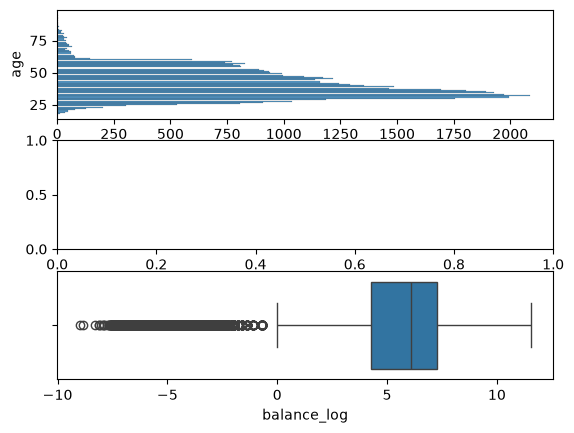

In [8]:
plt.subplots(3,1)
plt.subplot(3,1,1)
sns.histplot(data=data, y='age')
# plt.subplot(3,1,2)
# sns.boxplot(data=data, x='previous')
plt.subplot(3,1,3)
sns.boxplot(data=data, x='balance_log')

In [9]:
# data[data.previous==data.previous.max()]
# # extreme outlier, also didn't convert
# outlier_idx = np.where([data.previous==data.previous.max()])
# data = data.drop(outlier_idx[1])

<Axes: xlabel='balance_log'>

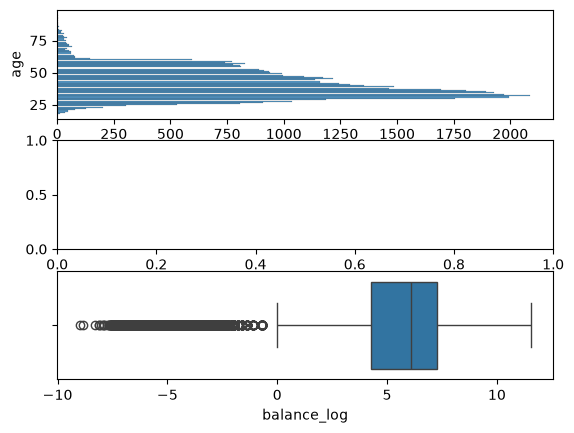

In [10]:
plt.subplots(3,1)
plt.subplot(3,1,1)
sns.histplot(data=data, y='age')
# plt.subplot(3,1,2)
# sns.boxplot(data=data, x='previous')
plt.subplot(3,1,3)
sns.boxplot(data=data, x='balance_log')

In [11]:
# data = pd.get_dummies(data, columns=["education"], drop_first=True)
# data_ndc = pd.get_dummies(data_ndc, columns=["education"], drop_first=False)
#moved to eda

In [12]:
data.columns

Index(['age', 'education', 'default', 'housing', 'loan',
       'previously_contacted', 'balance_negative', 'balance_log',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single'],
      dtype='str')

In [13]:
# features = data.drop(columns=['converted'])
# target = data.converted

In [14]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=0)

In [15]:
#scale for pca
from sklearn.preprocessing import StandardScaler


In [31]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.drop(columns=['balance_log'])) 
data_ndc_scaled = scaler.fit_transform(data_ndc) 

In [50]:
from sklearn.decomposition import PCA

In [53]:
data.shape

(45211, 22)

In [51]:
pca = PCA()
pca.fit(data_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >=0.95) +1

In [54]:
d, cumsum

(np.int64(17),
 array([0.11416269, 0.20916679, 0.28964865, 0.35933045, 0.41899644,
        0.47458259, 0.52827313, 0.57882209, 0.62841327, 0.67760284,
        0.7261537 , 0.77406343, 0.81828427, 0.86144412, 0.89888076,
        0.9330347 , 0.95769275, 0.97879591, 0.98870171, 0.99607165,
        1.        ]))

In [ ]:
pca = PCA()
pca.fit(data_ndc_scaled)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >=0.95) +1

In [ ]:
d

In [ ]:
pca = PCA(n_components=d)
pca_data = pca.fit_transform(data_scaled)

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import HDBSCAN
for min_size in [200, 500, 1000, 2000, 3200]:
    clusterer = HDBSCAN(min_cluster_size=min_size)
    pca_labels = clusterer.fit_predict(pca_data)
    pca_n_clusters = len(set(pca_labels)) - (1 if -1 in pca_labels else 0)
    noise_pct = (pca_labels == -1).sum() / len(pca_labels) * 100
    # Only calculate silhouette on non-noise points
    mask = pca_labels != -1
    score = silhouette_score(pca_data[mask], pca_labels[mask]) if mask.sum() > 1 else None
    print(f"min_size={min_size}: {n_clusters} clusters, {noise_pct:.1f}% noise, silhouette={score:.4f}")

In [ ]:
sns.lineplot(cumsum)

In [ ]:
# pca = PCA(31) 
# data_pca = pca.fit_transform(data_scaled) 

In [ ]:
# from sklearn.cluster import AgglomerativeClustering 
# cluster_model = AgglomerativeClustering(n_clusters=4) 
# data["Clusters"] = cluster_model.fit_predict(data_pca)

In [ ]:
from sklearn.cluster import KMeans, HDBSCAN
# k_means = KMeans(n_clusters=4)
# k_means.fit(data_pca)
# y_means = k_means.predict(data_pca)

In [ ]:
# from sklearn.cluster import KMeans
# k_means = KMeans(n_clusters=4)
# k_means.fit(data.drop(columns=['converted']))
# y_means = k_means.predict(data.drop(columns=['converted']))

In [ ]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters=4)
k_means.fit(data_scaled)
y_means = k_means.predict(data_scaled)

In [ ]:

# centers_original = pd.DataFrame(
#     centers_original,
#     columns=data.columns
# )

# print(centers_original)

In [ ]:

centers_original = pd.DataFrame(
    centers_original,
    columns=data.columns
)

print(centers_original)

In [ ]:
data["cluster"] = y_means

cluster_profile = data.groupby("cluster").mean()

In [ ]:
cluster_profile

In [ ]:
from sklearn.cluster import HDBSCAN
PARAM = ( {"min_cluster_size": 3200},{"min_cluster_size": 3400},{"min_cluster_size": 3600},{"min_cluster_size": 3800})



In [ ]:
PARAM

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for i, param in enumerate(PARAM):
    hdb = HDBSCAN(copy=True, **param).fit(data_scaled)
    labels = hdb.labels_

    axes[i].scatter(
        data_scaled[:, 0],
        data_scaled[:, 1],
        c=labels,
        cmap="tab10",
        s=10
    )
    axes[i].set_title(str(param))

plt.tight_layout()
plt.show()

In [ ]:
data_scaled.shape, data.shape

In [ ]:
data["cluster"].value_counts()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import HDBSCAN
import numpy as np
PARAM = [
    {"min_cluster_size": 200},
    {"min_cluster_size": 500},
    {"min_cluster_size": 1000},
    {"min_cluster_size": 2000},
    {"min_cluster_size": 3200},
]
results = []

for param in PARAM:
    hdb = HDBSCAN(copy=True, **param).fit(data_scaled)
    labels = hdb.labels_

    # Ignore noise points (-1)
    mask = labels != -1

    # Need at least 2 clusters
    n_clusters = len(set(labels[mask]))

    if n_clusters >= 2:
        score = silhouette_score(
            data_scaled[mask],
            labels[mask]
        )
    else:
        score = np.nan

    results.append((param, score))

results.sort(key=lambda x: x[1], reverse=True)

for param, score in results:
    print(score, param)

In [ ]:
for min_size in [200, 500, 1000, 2000, 3200]:
    clusterer = HDBSCAN(min_cluster_size=min_size)
    labels = clusterer.fit_predict(data_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    print(f"min_size={min_size}: {n_clusters} clusters, {noise_pct:.1f}% noise, silhouette={score:.4f}")

In [ ]:
# clusterer_cosine = HDBSCAN(min_cluster_size=1000, metric='cosine')
# labels_cosine = clusterer_cosine.fit_predict(data_scaled)
# n_clusters = len(set(labels_cosine)) - (1 if -1 in labels_cosine else 0)
# noise_pct = (labels_cosine == -1).sum() / len(labels_cosine) * 100
# print(f"cosine: {n_clusters} clusters, {noise_pct:.1f}% noise")
#too costly to run, crashes computer.

In [41]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import HDBSCAN
for min_size in [200, 500, 1000, 2000, 3200]:
    clusterer = HDBSCAN(min_cluster_size=min_size)
    labels = clusterer.fit_predict(data_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    # Only calculate silhouette on non-noise points
    mask = labels != -1
    score = silhouette_score(data_scaled[mask], labels[mask]) if mask.sum() > 1 else None
    print(f"min_size={min_size}: {n_clusters} clusters, {noise_pct:.1f}% noise, silhouette={score:.4f}")

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


min_size=200: 58 clusters, 15.8% noise, silhouette=0.4549


C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


min_size=500: 26 clusters, 23.3% noise, silhouette=0.4136


C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


min_size=1000: 12 clusters, 39.6% noise, silhouette=0.4007


C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


min_size=2000: 3 clusters, 76.5% noise, silhouette=0.5267


C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


TypeError: unsupported format string passed to NoneType.__format__

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import HDBSCAN
for min_size in [200, 500, 1000, 2000, 3200]:
    clusterer = HDBSCAN(min_cluster_size=min_size)
    labels = clusterer.fit_predict(data_ndc_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    mask = labels != -1
    score = silhouette_score(data_ndc_scaled[mask], labels[mask]) if mask.sum() > 1 else None
    print(f"min_size={min_size}: {n_clusters} clusters, {noise_pct:.1f}% noise, silhouette={score:.4f}")

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import HDBSCAN
for min_size in [3000, 3400]:
    clusterer = HDBSCAN(min_cluster_size=min_size)
    labels = clusterer.fit_predict(data_ndc_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    mask = labels != -1
    score = silhouette_score(data_ndc_scaled[mask], labels[mask]) if mask.sum() > 1 else None
    print(f"min_size={min_size}: {n_clusters} clusters, {noise_pct:.1f}% noise, silhouette={score:.4f}")

In [ ]:
from sklearn.cluster import KMeans
for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(data_scaled)
    score = silhouette_score(data_scaled, labels)
    print(f"k={k}: silhouette={score:.4f}")

In [32]:
from sklearn.cluster import HDBSCAN
hdb = HDBSCAN(min_cluster_size=1000).fit(data_scaled)
import pandas as pd

pd.Series(hdb.labels_).value_counts()

C:\Users\clair\documents\ironhack\final_project\Final-Project\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


-1     17892
 9      5404
 6      4726
 5      3169
 4      2110
 11     1749
 8      1746
 7      1735
 3      1457
 2      1394
 10     1343
 1      1269
 0      1217
Name: count, dtype: int64

In [ ]:
import numpy as np
from permetrics import ClusteringMetric

## For integer labels or categorical labels
# data = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]])
y_pred = hdb.labels_

cm = ClusteringMetric(X=data_scaled, y_pred=y_pred)

print(cm.density_based_clustering_validation_index())
print(cm.DBCVI())

In [40]:
import numpy as np
from permetrics import ClusteringMetric
mask = hdb.labels_ != -1

cm = ClusteringMetric(
    X=data_scaled[mask],
    y_pred=hdb.labels_[mask]
)

print(cm.DBCVI())

0.9615014725860046


In [ ]:
from hdbscan import validity_index
validity_index(data_scaled, hdb.labels_)

In [ ]:
pd.DataFrame(data_scaled).head()

In [ ]:
data.columns

In [33]:
data["hdb_cluster"] = hdb.labels_

data.groupby("hdb_cluster").mean(numeric_only=True)

,age,education,default,housing,loan,previously_contacted,balance_negative,balance_log,job_blue-collar,job_entrepreneur,...,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single
hdb_cluster,,,,,,,,,,,,,,,,,,,,,
-1,39.767494,1.012631,0.045551,0.582495,0.329421,0.355298,0.202828,3.573556,0.241896,0.005198,...,0.258831,0.008607,0.006819,0.055053,0.052426,0.160463,0.0019,0.016097,0.492287,0.351666
0,46.517666,0.562038,0.000000,0.320460,0.116680,0.124076,0.023829,5.237835,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.736237,0.115859
1,41.012608,0.985816,0.000000,0.410559,0.078014,0.164697,0.042553,5.421907,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0000,0.000000,0.561860,0.308117
2,42.245337,1.241033,0.000000,0.586083,0.222382,0.154232,0.038020,5.201739,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.729555,0.149928
3,40.499657,1.419355,0.000000,0.472889,0.126973,0.175704,0.000686,5.935818,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.623885,0.287577
4,62.125118,0.709953,0.000000,0.199052,0.116114,0.220853,0.000000,6.238462,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.780569,0.038389
5,39.041654,0.925213,0.000000,0.682865,0.116441,0.132849,0.000000,5.639487,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0000,0.000000,0.630167,0.249290
6,39.001481,1.252645,0.000000,0.494287,0.000000,0.038510,0.000000,5.710309,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0000,0.000000,0.544223,0.342361
7,33.386744,1.956196,0.000000,0.433429,0.000000,0.000000,0.000000,5.908775,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,1.000000


In [34]:
# data['hdb_cluster'] = labels
conversion_by_cluster = data2.groupby(data['hdb_cluster'])['converted'].mean()
print(conversion_by_cluster)

hdb_cluster
-1     0.134138
 0     0.088743
 1     0.157604
 2     0.080344
 3     0.120796
 4     0.238863
 5     0.082991
 6     0.103259
 7     0.141787
 8     0.085338
 9     0.062916
 10    0.058824
 11    0.128073
Name: converted, dtype: float64


In [42]:
data2['hdb_cluster'] = hdb.labels_


In [43]:
bf = pd.read_csv(config['data']['clean']['file2'], quotechar='"', sep = ";")
bf['hdb_cluster'] = hdb.labels_

In [44]:

bf[bf['hdb_cluster'].isin([3,5])].groupby('hdb_cluster')['job'].value_counts()

hdb_cluster  job          
3            self-employed    1457
5            services         3169
Name: count, dtype: int64

In [45]:
bf.groupby('hdb_cluster').agg({
    'job': lambda x: x.value_counts().index[0],  
    'marital': lambda x: x.value_counts().index[0],
    'poutcome': lambda x: x.value_counts().index[0],
    'contact': lambda x: x.value_counts().index[0],
    'education': lambda x: x.value_counts().index[0],
    'age': 'mean',
    'balance': 'mean',
    'y': lambda x: x.value_counts().index[0]    
}).round(3)

,job,marital,poutcome,contact,education,age,balance,y
hdb_cluster,,,,,,,,
-1,management,married,unknown,cellular,secondary,39.767,1073.997,no
0,housemaid,married,unknown,cellular,primary,46.518,1422.671,no
1,unemployed,married,unknown,cellular,secondary,41.013,1565.597,no
2,entrepreneur,married,unknown,cellular,tertiary,42.245,1629.297,no
3,self-employed,married,unknown,cellular,tertiary,40.500,1780.344,no
4,retired,married,unknown,cellular,secondary,62.125,2136.540,no
5,services,married,unknown,cellular,secondary,39.042,1192.357,no
6,technician,married,unknown,cellular,secondary,39.001,1417.693,no
7,management,single,unknown,cellular,tertiary,33.387,1829.363,no


In [46]:
bf.groupby('hdb_cluster').agg({
    'age': ['mean', 'median', 'std'],
    'balance': ['mean', 'median', 'std'],
    'job': lambda x: x.value_counts().index[0],
    'marital': lambda x: x.value_counts().index[0],
    'education': lambda x: x.value_counts().index[0],
    'y': lambda x: x.value_counts(normalize=True).iloc[0]
})

age                        balance                      \
                  mean median        std         mean median          std   
hdb_cluster                                                                 
-1           39.767494   38.0  10.294774  1073.997429  305.5  2683.936587   
 0           46.517666   47.0  10.448962  1422.671323  420.0  3003.095384   
 1           41.012608   40.0   9.794570  1565.597321  557.0  3174.094761   
 2           42.245337   41.5   9.039202  1629.296987  404.0  4263.042459   
 3           40.499657   39.0   9.542640  1780.343857  596.0  3784.648871   
 4           62.125118   60.0   9.343479  2136.540284  918.5  4514.618741   
 5           39.041654   38.0   8.803095  1192.356579  450.0  2279.558570   
 6           39.001481   37.0   8.526051  1417.693398  507.5  2594.572251   
 7           33.386744   32.0   5.333594  1829.363112  635.0  3427.309090   
 8           38.984536   38.0   7.470307  1303.553837  506.0  2795.021027   
 9           40.631939   40.0   8.792495  1297.588823  518.0  2474.026487   
 10          39.332092   38.0   7.116964  1811.020849  625.0  3402.867345   
 11          42.980560   42.0   8.858129  2235.201258  705.0  4854.173411   

                       job  marital  education         y  
                  <lambda> <lambda>   <lambda>  <lambda>  
hdb_cluster                                               
-1              management  married  secondary  0.865862  
 0               housemaid  married    primary  0.911257  
 1              unemployed  married  secondary  0.842396  
 2            entrepreneur  married   tertiary  0.919656  
 3           self-employed  married   tertiary  0.879204  
 4                 retired  married  secondary  0.761137  
 5                services  married  secondary  0.917009  
 6              technician  married  secondary  0.896741  
 7              management   single   tertiary  0.858213  
 8                  admin.  married  secondary  0.914662  
 9             blue-collar  married  secondary  0.937084  
 10             management  married   tertiary  0.941176  
 11             management  married   tertiary  0.871927

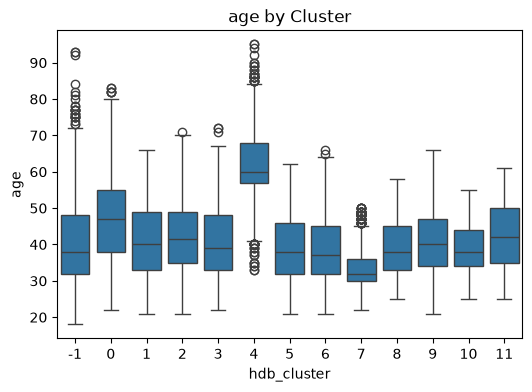

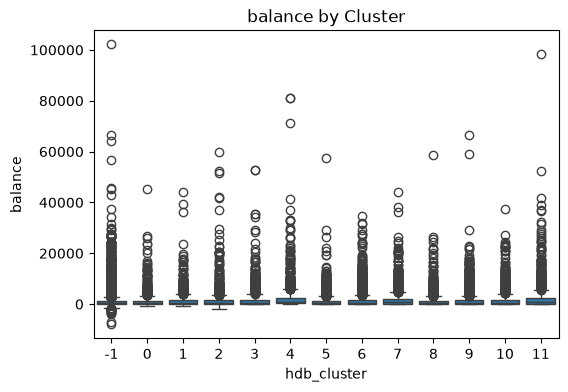

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['age', 'balance']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='hdb_cluster', y=col, data=bf)
    plt.title(col + ' by Cluster')
    plt.show()

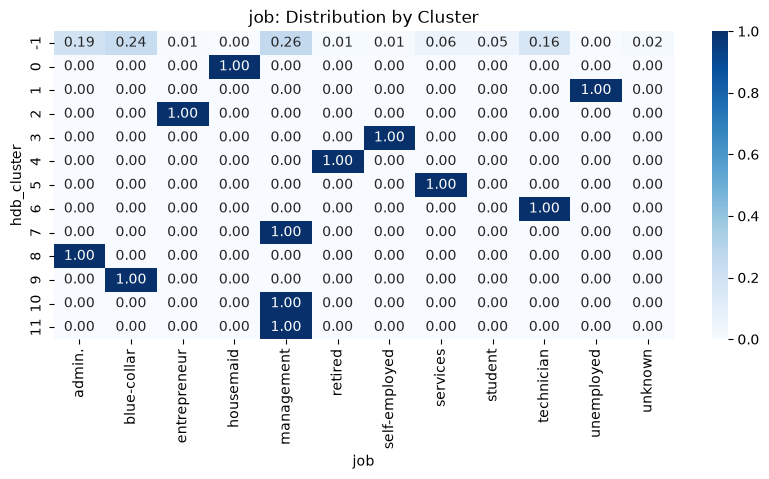

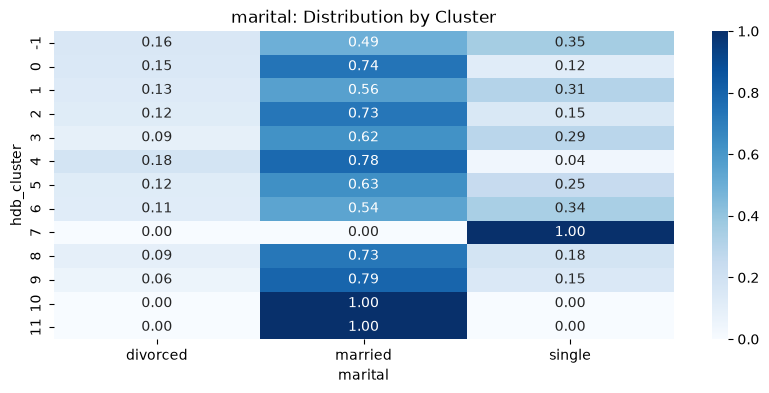

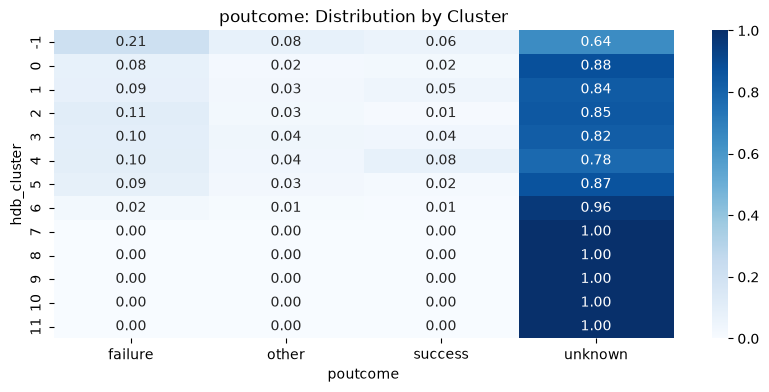

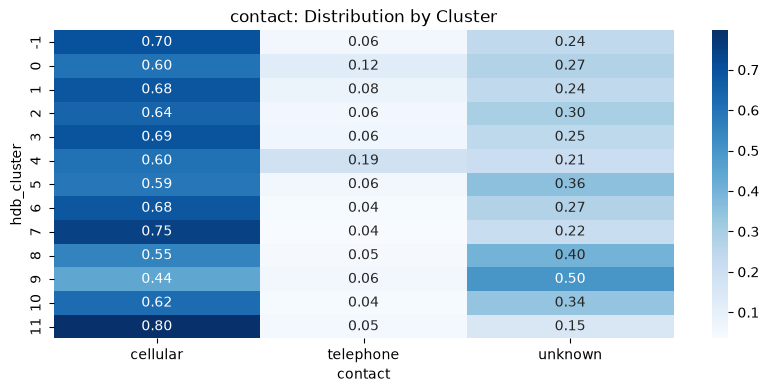

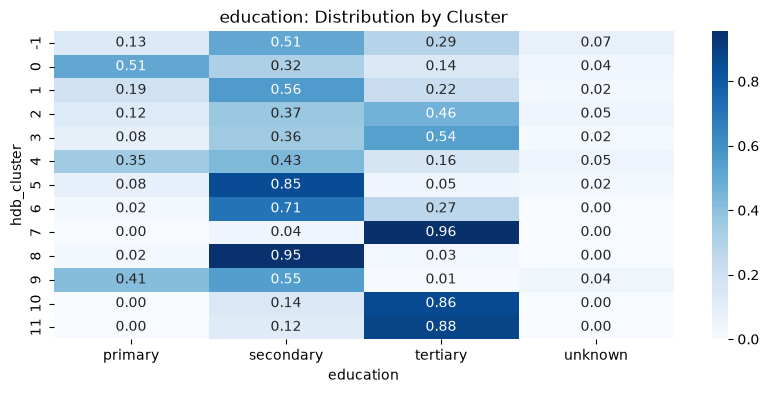

In [48]:
cat_cols = ['job', 'marital', 'poutcome', 'contact', 'education']

for col in cat_cols:
    ct = pd.crosstab(bf['hdb_cluster'], bf[col], normalize='index')
    
    plt.figure(figsize=(10,4))
    sns.heatmap(ct, annot=True, cmap='Blues', fmt='.2f')
    plt.title(f'{col}: Distribution by Cluster')
    plt.show()

In [49]:
pd.crosstab(bf['hdb_cluster'], bf['job'], normalize='index')

job,admin.,blue-collar,entrepreneur,housemaid,management,retired,self-employed,services,student,technician,unemployed,unknown
hdb_cluster,,,,,,,,,,,,
-1,0.191426,0.241896,0.005198,0.001285,0.258831,0.008607,0.006819,0.055053,0.052426,0.160463,0.0019,0.016097
0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0000,0.000000
2,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.0000,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.0000,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0000,0.000000
7,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000


In [30]:
from sklearn.linear_model import LogisticRegression

X = data[['balance_log']]
y = data['hdb_cluster']

model = LogisticRegression(max_iter=1000)
model.fit(X, y)
print(model.score(X, y))

0.7681537678883458


In [ ]:
# from sklearn.manifold import Isomap, TSNE
# from sklearn.cluster import HDBSCAN

# isomap = Isomap(n_components=10, n_neighbors=15)
# X_isomap = isomap.fit_transform(data_scaled)


# clusterer = HDBSCAN(min_cluster_size=1000)
# labels = clusterer.fit_predict(X_isomap)
#running causes laptop to crash

In [ ]:
data.columns

In [ ]:
bf.columns